In [3]:
import pandas as pd
import json
import geopandas as gpd
import random
import shapely
from shapely.geometry import box
import rasterio
from rasterio.features import geometry_window
from rasterio.windows import Window
from rasterio.mask import mask
from shapely.geometry import Polygon,MultiPolygon

import gc
import tqdm 

import sys
import json 
import copy
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib import colors
import torchvision
import torch.nn.functional as F
import pandas as pd
from matplotlib.colors import ListedColormap


In [4]:

municipalities = gpd.read_file('../data/inference/municipalities_amazon_biome/municipalities_amazon_biome.shp')
municipalities = municipalities.to_crs(4326)

inference_area = gpd.read_file('../data/inference/inference_area.gpkg').to_crs(4326)

ERROR 1: PROJ: proj_create_from_database: Open of /home/jan/miniconda3/envs/torch/share/proj failed


In [6]:
from torchmetrics.functional import jaccard_index, precision, recall, f1_score 
from sklearn.metrics import average_precision_score, roc_auc_score

def compute_metrics(targets, preds):

    preds = preds.to(dtype=torch.float16)
    targets = targets.to(dtype=torch.int16)

    mask = targets != -1
    valid_targets = targets[mask].flatten()
    valid_preds = preds[mask].flatten()

    metrics = {
        f'iou' : jaccard_index(preds, targets, task='binary', num_classes=1, ignore_index=-1),
        f'f1' : f1_score(preds, targets, task='binary', num_classes=1, ignore_index=-1),
        f'precision' : precision(preds, targets, task='binary', num_classes=1, ignore_index=-1),
        f'recall' : recall(preds, targets, task='binary', num_classes=1, ignore_index=-1),
        f'average_precision' : average_precision_score(valid_targets.flatten(), valid_preds.flatten()),
        #f'ROC_AUC' : roc_auc_score(valid_targets.flatten(), valid_preds.flatten()),
        "n_valid": int(mask.sum().detach().cpu().item()),
        "n_positive": int((valid_targets == 1).sum().detach().cpu().item()),
        "n_predicted": int((valid_preds >= 0.5).sum().detach().cpu().item()),
    }
    return metrics


        
        # --- add metrics directly to states gdf ---
def _to_py(v):
    # torch scalar -> float, numpy scalar -> python scalar, else passthrough
    if hasattr(v, "detach"):
        return float(v.detach().cpu().item())
    if hasattr(v, "item"):
        try:
            return v.item()
        except Exception:
            return v
    return v



import rasterio
from rasterio.windows import from_bounds
from rasterio.transform import array_bounds

def crop_to_true_intersection(pred_arr, pred_tr, targ_arr, targ_tr):
    """
    pred_arr, targ_arr: (1,H,W)
    pred_tr, targ_tr: Affine transforms for these cropped arrays
    returns: pred_arr2, targ_arr2 with identical shape and identical geographic extent
    """

    Hp, Wp = pred_arr.shape[1], pred_arr.shape[2]
    Ht, Wt = targ_arr.shape[1], targ_arr.shape[2]

    # geographic bounds of each cropped array
    pl, pb, pr, pt = array_bounds(Hp, Wp, pred_tr)
    tl, tb, tr, tt = array_bounds(Ht, Wt, targ_tr)

    # intersection in map coordinates
    left   = max(pl, tl)
    bottom = max(pb, tb)
    right  = min(pr, tr)
    top    = min(pt, tt)

    if left >= right or bottom >= top:
        raise ValueError("No geographic overlap between the two cropped rasters.")

    # windows into each array for that same geographic intersection
    wp = from_bounds(left, bottom, right, top, transform=pred_tr).round_offsets().round_lengths()
    wt = from_bounds(left, bottom, right, top, transform=targ_tr).round_offsets().round_lengths()

    pred_arr2 = pred_arr[:, wp.row_off:wp.row_off + wp.height, wp.col_off:wp.col_off + wp.width]
    targ_arr2 = targ_arr[:, wt.row_off:wt.row_off + wt.height, wt.col_off:wt.col_off + wt.width]

    # ensure identical shape (should be, but guard against rounding edge cases)
    h = min(pred_arr2.shape[1], targ_arr2.shape[1])
    w = min(pred_arr2.shape[2], targ_arr2.shape[2])
    pred_arr2 = pred_arr2[:, :h, :w]
    targ_arr2 = targ_arr2[:, :h, :w]

    return pred_arr2, targ_arr2





In [11]:
import os
import rasterio


for year in [2016,2017,2018]:
    print(year)

    predictions_path = f'../data/inference/predictions/{year}.tif'
    
    #Need to run src/scripts/accumulate_target_rasters.py
    target_path = f'../data/accumulated_deforestation/accum_{year}.tif'

    inference_area_geom = inference_area.geometry.iloc[0]

    with rasterio.open(predictions_path) as pred_ds, rasterio.open(target_path) as targ_ds:
        if pred_ds.crs != targ_ds.crs:
            raise ValueError("Pred and target rasters must have the same CRS.")

        municipalities_raster_crs = municipalities.to_crs(pred_ds.crs)

        for i, row in tqdm.tqdm(municipalities_raster_crs.iterrows()):
            geom = row.geometry

            geom = geom.intersection(inference_area_geom)
            if geom is None or geom.is_empty:
                continue

            pred_arr, pred_tr = mask(pred_ds, [geom], crop=True, filled=True, nodata=65535, pad=True)
            targ_arr, targ_tr = mask(targ_ds, [geom], crop=True, filled=True, nodata=-1, pad=True)

            if pred_arr.shape != targ_arr.shape:
                pred_arr, targ_arr = crop_to_true_intersection(pred_arr, pred_tr, targ_arr, targ_tr)

            preds_t = torch.from_numpy(pred_arr[0].astype(np.float32, copy=False)).unsqueeze(0)
            non_predicted_mask = preds_t == 65535
            #Skipped areas are counted as negative predictions
            preds_t[preds_t == 65535] = 0
            preds_t = preds_t / 65534

            targs_t = torch.from_numpy(targ_arr[0].astype(np.int16, copy=False)).unsqueeze(0)
            try:

                metrics1 = compute_metrics(targs_t, preds_t)
            except Exception as e:
                print(e)
                continue

            #print(metrics1)


            for k, v in metrics1.items():
                municipalities.loc[row.name, f"{k}_{year}"] = _to_py(v)


2016


68it [01:13,  2.20it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
102it [01:24,  1.32it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
154it [04:10,  2.03s/it]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
203it [08:09,  6.44s/it]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
227it [09:33,  2.70s/it]

cannot do a non-empty take from an empty axes.


392it [17:29, 10.43s/it]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
415it [18:14,  1.66it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
455it [18:31,  9.06it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
559it [18:55,  2.03s/it]


2017


...

392it [17:14, 10.55s/it]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
415it [18:00,  1.62it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
455it [18:18,  9.01it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
559it [18:43,  2.01s/it]


2018


68it [01:02,  2.68it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
203it [07:46,  6.37s/it]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
227it [09:11,  2.76s/it]

cannot do a non-empty take from an empty axes.


392it [17:07, 10.53s/it]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
415it [17:55,  1.56it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
455it [18:13,  8.70it/s]/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
559it [18:39,  2.00s/it]


In [12]:
#The metrics 
municipalities.to_file('../data/results/metrics_by_municipalities.gpkg')

In [14]:
gdf = municipalities
if gdf.crs.is_geographic:
    gdf = gdf.to_crs(5880)

gdf["area"] = gdf.geometry.area
gdf["n_positive_per_km2"] = gdf["n_positive_2018"] / (gdf["area"] / 1e6)


# Plotting

In [204]:
import matplotlib.font_manager as fm
fm.fontManager = fm.FontManager()
import matplotlib as mpl
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial"]

## Predicted vs. observed 

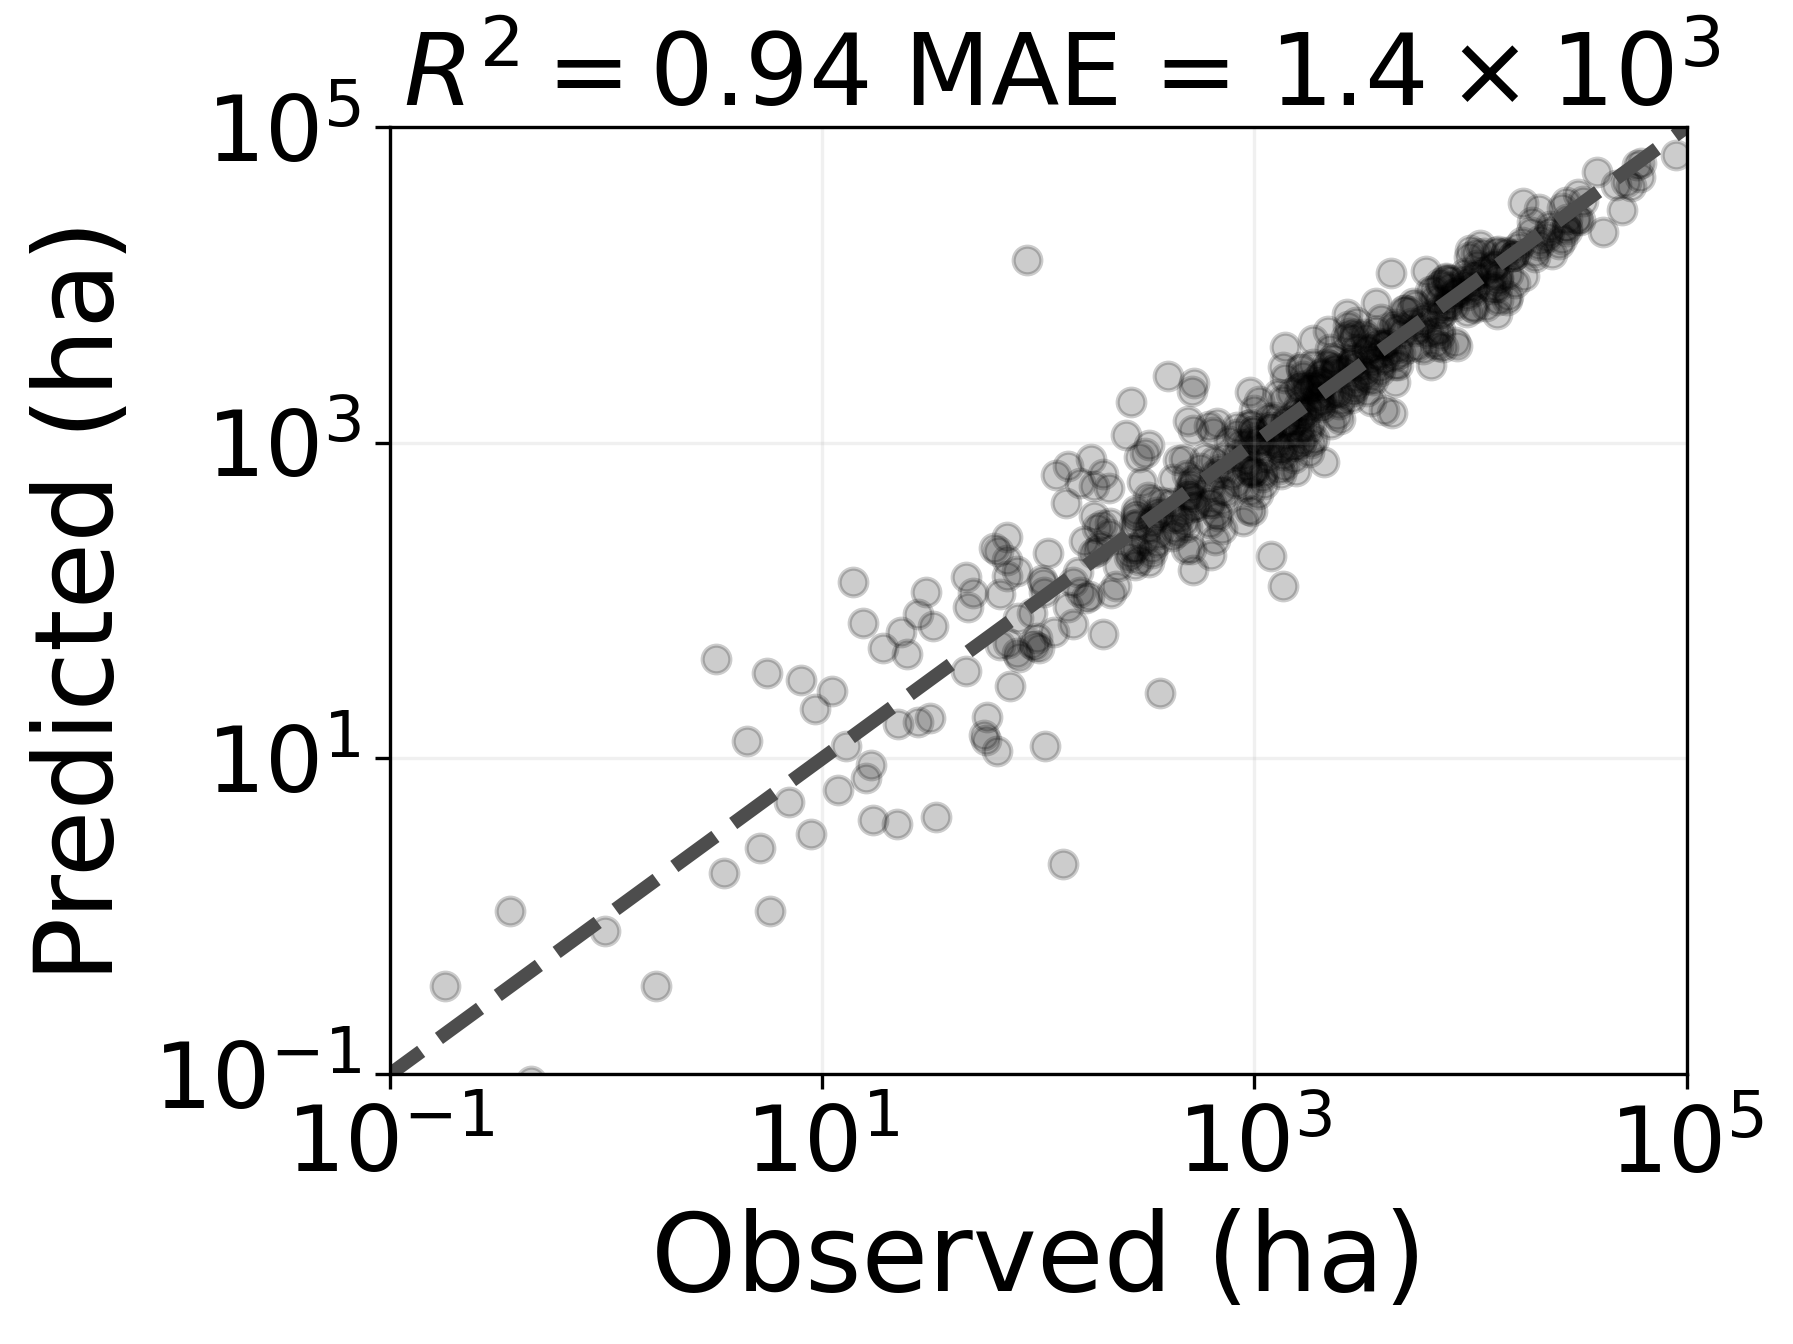

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Data
px_to_ha = 0.09
x = gdf["n_positive_2018"] * px_to_ha
y = gdf["n_predicted_2018"] * px_to_ha
mask = (x > 0) & (y > 0)

# Metrics
r2_lin = r2_score(x[mask], y[mask])
mae = mean_absolute_error(x[mask], y[mask])
rmae_pct = 100 * mae / np.mean(x[mask])

import math

m = math.floor(math.log10(abs(mae)))
mae = mae / 10**m

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=300)

ax.scatter(
    x[mask], y[mask],
    s=44,                     # smaller markers
    alpha=0.2,
    color="black"
    #linewidth=0.3,
)

# 1:1 line
lo = min(x[mask].min(), y[mask].min())
hi = max(x[mask].max(), y[mask].max())
ax.plot([lo, hi], [lo, hi], "--", linewidth=3.3, color="0.3")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 1e5)
ax.set_ylim(1e-1, 1e5)

ax.grid(True, which="major", alpha=0.18)
ax.minorticks_off()

ax.set_xlabel("Observed (ha)")
ax.set_ylabel("Predicted (ha)")




ax.text(
    0.01, 1.0,
    r"$R^2 = 0.94$ MAE = $1.4 \times 10^3$",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=24
)



plt.tight_layout()
#plt.show()

plt.savefig("predicted_observed_reg_plot.png", dpi=300, bbox_inches="tight")

## Amazon-wise performance


In [230]:
TP = (df["recall_2018"] * df["n_positive_2018"]).sum()
FP = (df["n_predicted_2018"] - df["recall_2018"] * df["n_positive_2018"]).sum()
FN = (df["n_positive_2018"] - df["recall_2018"] * df["n_positive_2018"]).sum()

precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

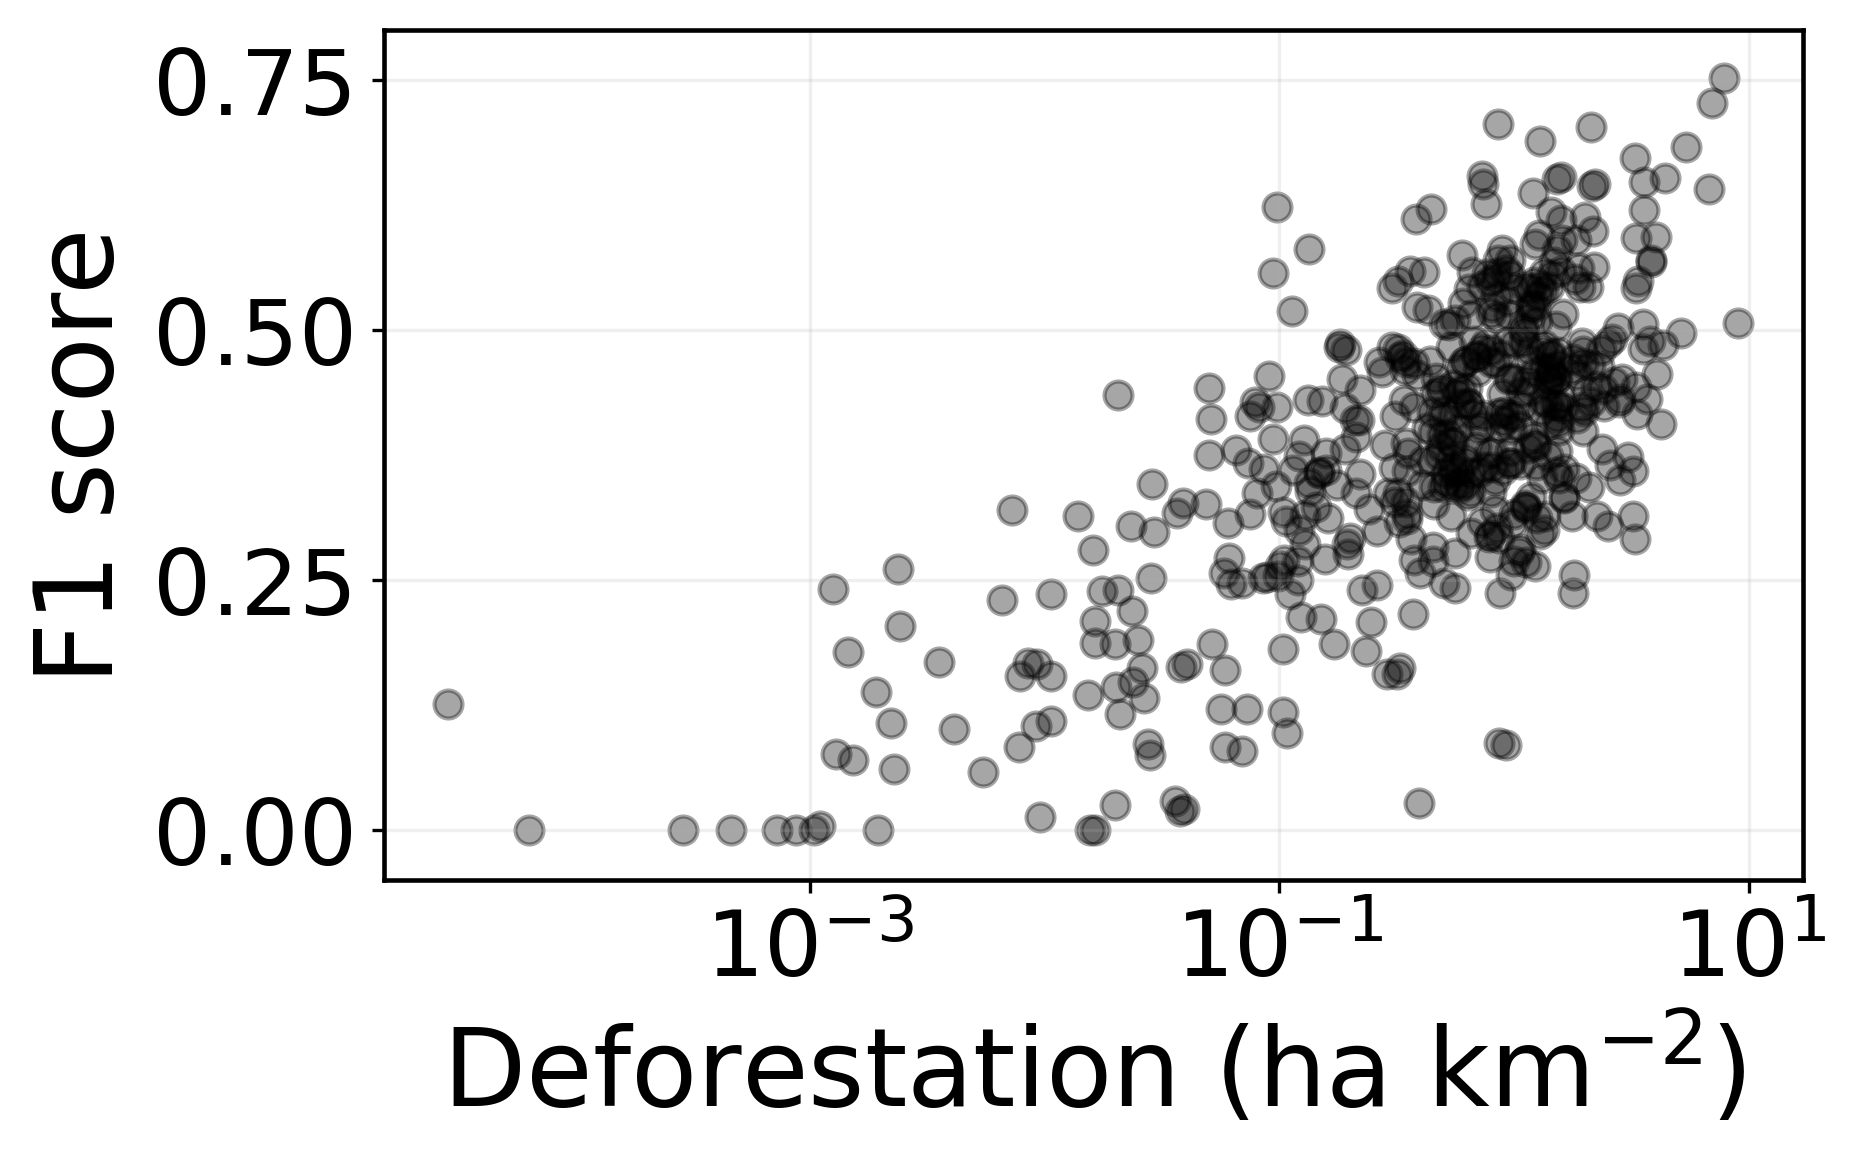

In [419]:
import matplotlib.pyplot as plt

# Data
x = gdf["n_positive_per_km2"] * px_to_ha
y = gdf["f1_2018"]

mask = x > 0

# Global style
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})


fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)

plt.scatter(
    x[mask], y[mask],
    s=45,
    alpha=0.35,
    color="black"
)

plt.xscale("log")
plt.ylim(-0.05, 0.8)

plt.grid(True, which="major", alpha=0.2)
plt.minorticks_off()

plt.xlabel("Deforestation (ha km$^{-2}$)")
plt.ylabel("F1 score")

plt.tight_layout()
#plt.show()

plt.savefig("f1_density.png", dpi=300, bbox_inches="tight")


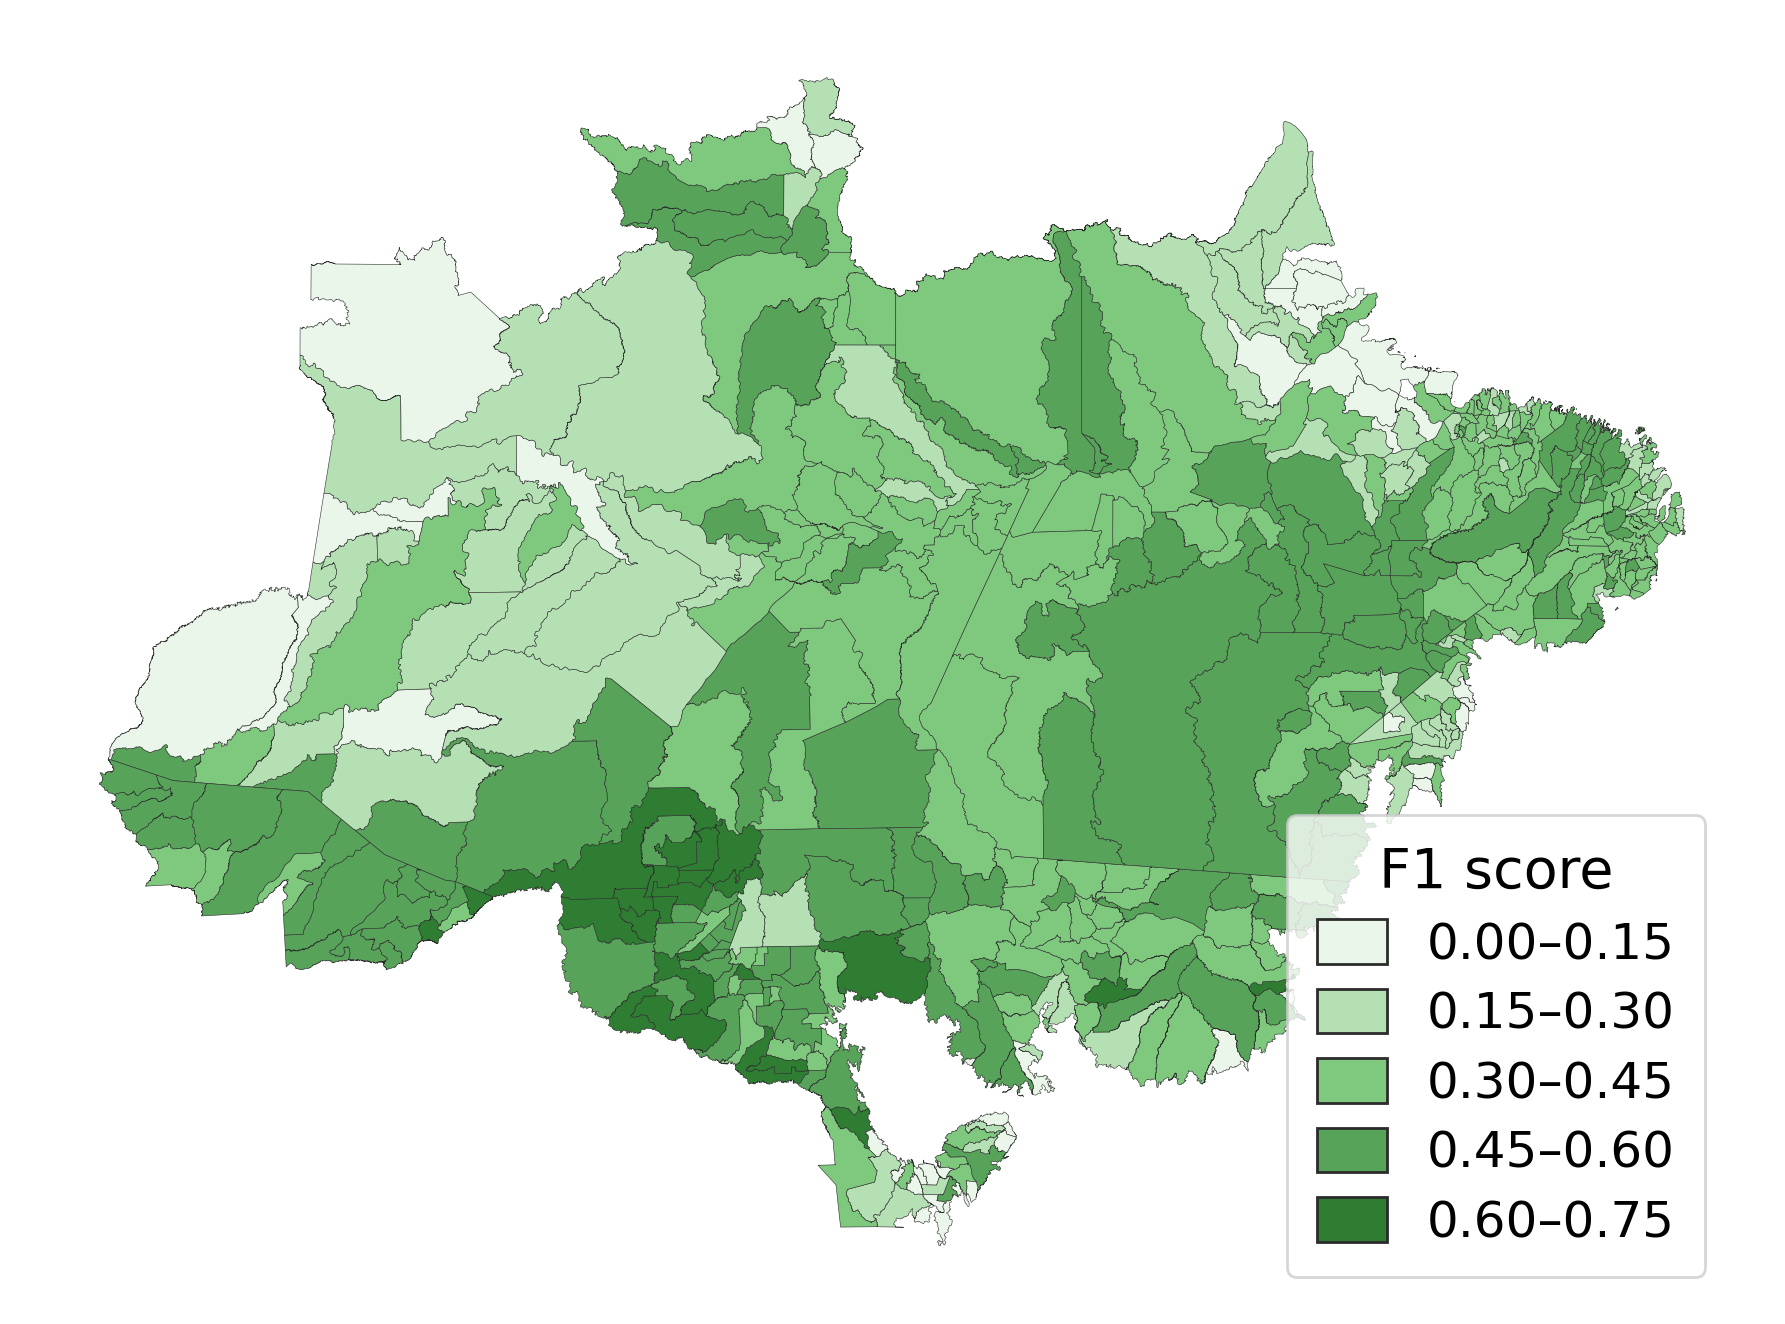

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# --- data range ---
vals = _gdf["f1_2018"].to_numpy(float)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))

# --- fewer classes for legibility ---
n_classes = 5
bins = np.linspace(vmin, vmax, n_classes + 1)

# --- colormap ---
cmap = LinearSegmentedColormap.from_list(
    "custom_green",
    ["#eaf6ea", "#7fc97f", "#2f7d32"],
    N=n_classes,
)
norm = mpl.colors.BoundaryNorm(bins, ncolors=n_classes, clip=True)

# --- figure ---
fig, ax = plt.subplots(figsize=(12, 7), dpi=200)

_gdf.plot(
    ax=ax,
    column="f1_2018",
    cmap=cmap,
    norm=norm,
    linewidth=0.2,
    edgecolor="#2b2b2b",
    legend=False,
    missing_kwds={"color": "#e6e6e6"},
)

# --- legend ---
handles = [
    mpl.patches.Patch(facecolor=cmap(i), edgecolor="#2b2b2b")
    for i in range(n_classes)
]
labels = [f"{bins[i]:.2f}–{bins[i+1]:.2f}" for i in range(n_classes)]

leg = ax.legend(
    handles,
    labels,
    title="F1 score",
    #loc="lower right",
    bbox_to_anchor=(0.98, 0.4), 
    frameon=True,
    fontsize=18,          # BIG labels
    title_fontsize=20,    # BIG title
    borderpad=0.6,
    labelspacing=0.4,     # compact vertical spacing
    handlelength=1.4,
    handleheight=1.0,
)

ax.set_axis_off()
plt.tight_layout()
#plt.show()
plt.savefig("f1_per_munic.png", dpi=300, bbox_inches="tight")

In [8]:
_gdf = gdf.loc[gdf.n_positive_2018 > 0]
_gdf['predicted_vs_observed'] = _gdf['n_predicted_2018'] / _gdf['n_positive_2018'] 

/home/jan/miniconda3/envs/torch/lib/python3.11/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


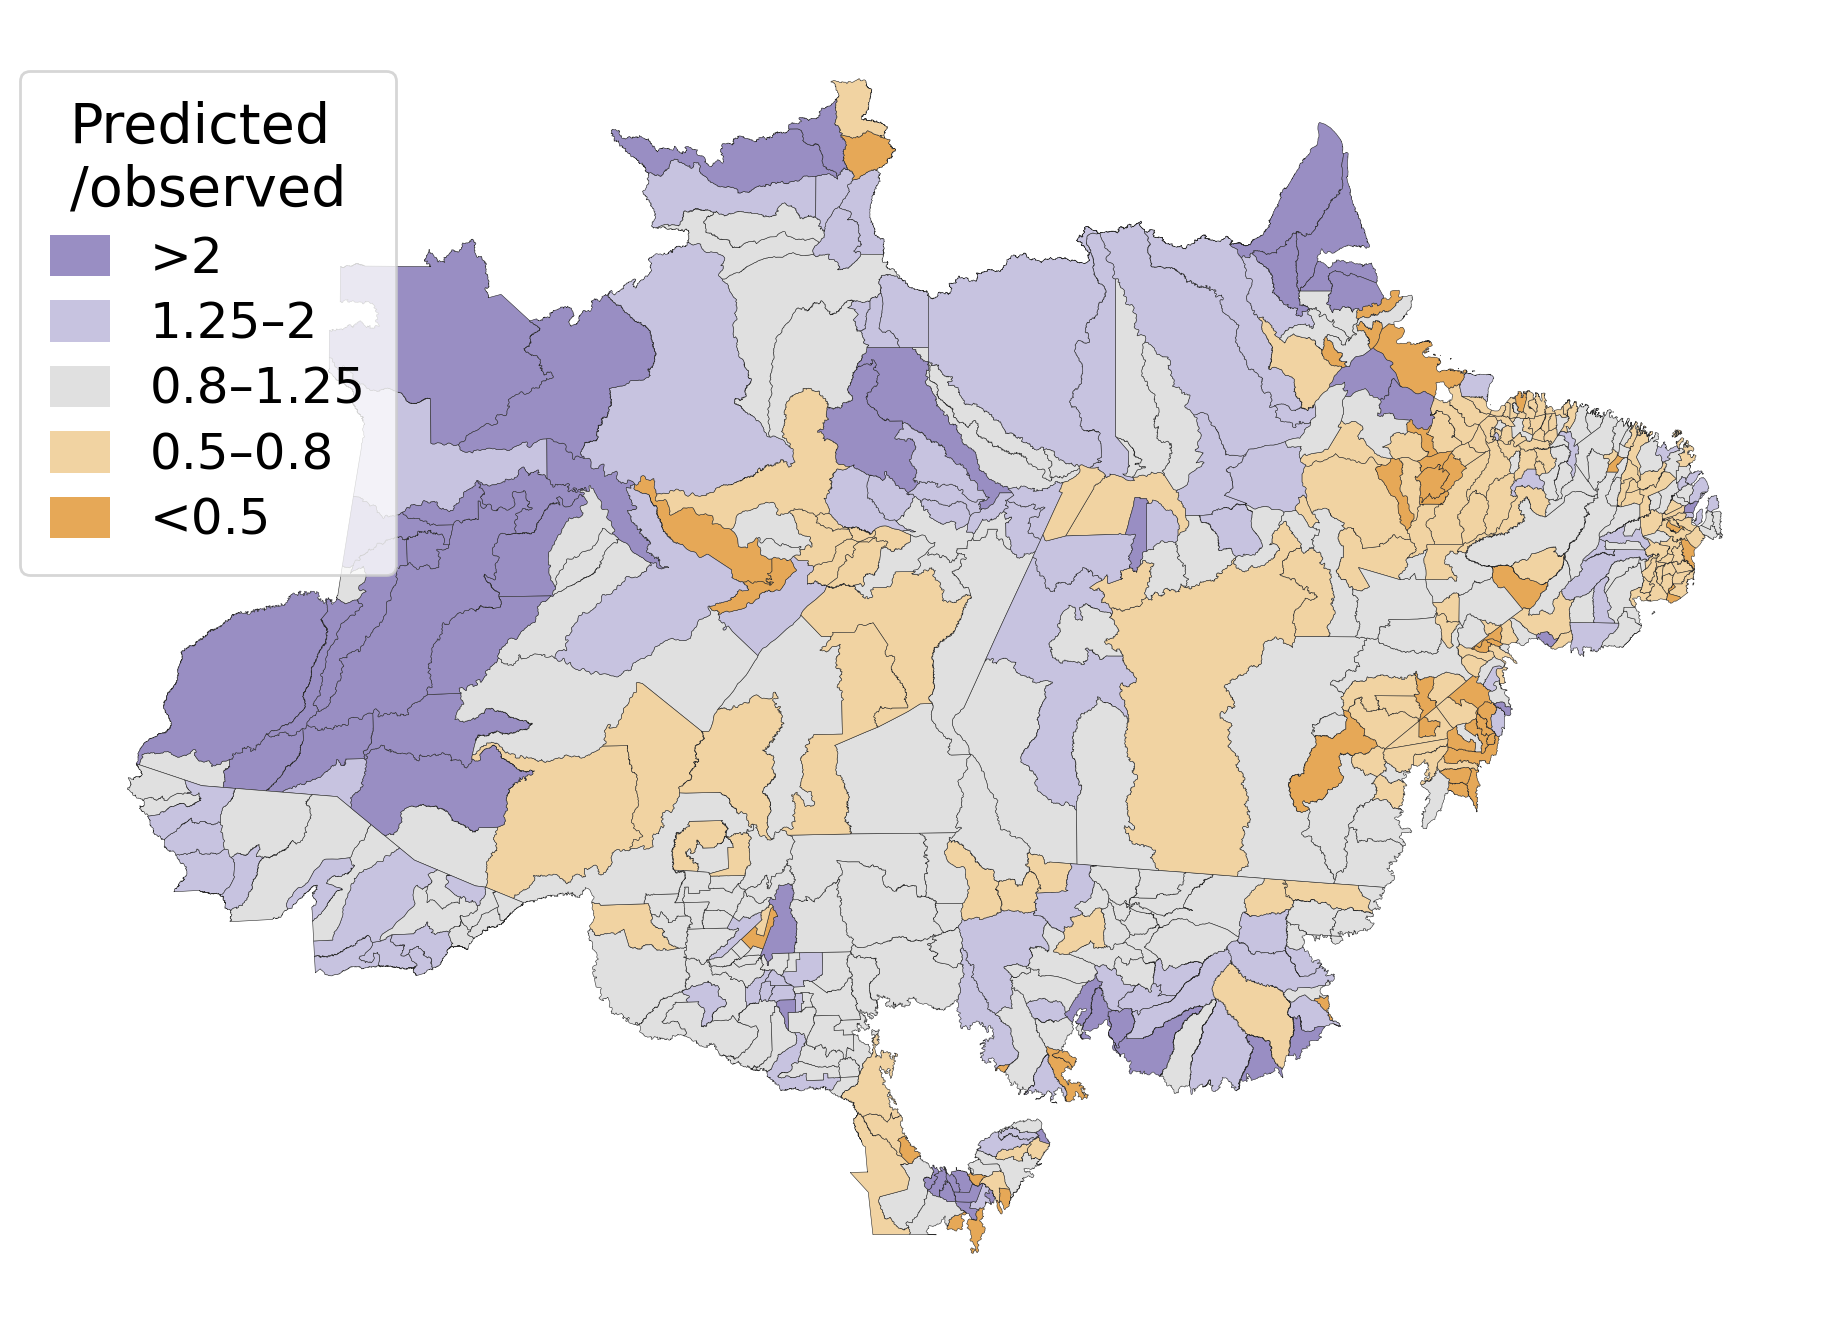

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

_gdf = _gdf.copy()

pred = _gdf["n_predicted_2018"].astype(float)
obs  = _gdf["n_positive_2018"].astype(float)

eps = 0.5
_gdf["ratio"] = (pred + eps) / (obs + eps)

# --- safe bin edges (no 0 / inf) ---
ratio_finite = _gdf["ratio"].to_numpy()
ratio_finite = ratio_finite[np.isfinite(ratio_finite)]

low_edge  = max(np.nanmin(ratio_finite), 1e-12)
high_edge = np.nanmax(ratio_finite)

low_edge  = min(low_edge, 0.5) * 0.999
high_edge = max(high_edge, 2.0) * 1.001

bins = np.array([low_edge, 0.5, 0.8, 1.25, 2.0, high_edge], dtype=float)

labels = [
    ">2",
    "1.25–2",
    "0.8–1.25",
    "0.5–0.8",
    "<0.5",
]



colors = ["#e6a857", "#f1d3a2", "#e0e0e0", "#c7c3e0", "#998ec3"]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N, clip=True)

# --- big fonts + small-view friendly ---
plt.rcParams.update({
    "font.size": 18,
    "legend.fontsize": 18,
})

fig, ax = plt.subplots(figsize=(12, 7), dpi=200)

_gdf.plot(
    ax=ax,
    column="ratio",
    cmap=cmap,
    norm=norm,
    linewidth=0.2,
    edgecolor="#2b2b2b",
)

ax.set_axis_off()

handles = [Patch(facecolor=c, edgecolor="none") for c in colors][::-1]

leg = ax.legend(
    handles=handles,
    labels=labels,
    title = "Predicted\n/observed",
    loc="upper left",
    bbox_to_anchor=(-0.03, 0.98), 
    frameon=True,
    #framealpha=1.0,
    borderpad=0.6,
    labelspacing=0.35,
    handlelength=1.2,
    handleheight=0.9,
)


leg.get_title().set_fontsize(20)
leg.get_frame().set_edgecolor("#cccccc")
leg.get_frame().set_linewidth(1.0)

plt.tight_layout()
#plt.show()
plt.savefig("predicted_observed_spatial_2.png", dpi=300, bbox_inches="tight")